In [51]:
def mnk(X, Y):
    N = len(X)
    
    XY = [X[i]*Y[i] for i in range(N)]
    X2 = [x*x for x in X]
    Y2 = [y*y for y in Y]
    
    _xy = sum(XY)/len(XY)
    _x = sum(X)/N
    _y = sum(Y)/N
    _x2 = sum(X2)/N
    _y2 = sum(Y2)/N

    b = (_xy - _x*_y)/(_x2 - _x*_x)
    a = _y - b*_x

    sb = (((_y2 - _y**2)/(_x2 - _x**2) - b**2)*(1/N))**0.5
    sa = sb*(_x2-_x*_x)**0.5
    
    return (b, a, sb, sa)

In [52]:
file_name = "3.3.txt"
N = 9
file = open(file_name, 'r')
A = [line.replace(',', '.').split() for line in file]
file.close()
d = [float(a[1]) for a in A]
m = [float(a[0]) for a in A]
dm = [0.3, 0.4, 0.5, 0.6, 0.7, 0.6, 0.5, 0.4, 0.3]
em = [dm[i]/m[i] for i in range(len(m))]
dd = 1
ed = [dd/x for x in d]
# х - в граммах, у - в мм

In [53]:
# в метрах:
L =  1.540
dL = 0.001
eL = dL/L

r =  0.05360
dr=  0.00005
er = dr/r

l =  1.330
dl = 0.002
el = dl/l

g= 9.8

In [54]:
m = [x/1000 for x in m]
d = [x/1000 for x in d]

In [55]:
F = [x/L for x in d] # углы

eF = [(x**2 + eL**2)**0.5 for x in ed]

dF = [F[i]*eF[i] for i in range(len(F))]

M = [2*x*g*r for x in m] #моменты

eM = [(x**2 + er**2)**0.5 for x in em]

dM = [M[i]*eM[i] for i in range(len(M))]


In [58]:
b, a, sb, sa = mnk(M, F)

f = 1/b # модуль кручения

ef = (max(eF)**2 + max(eM)**2)**0.5

df_sys = f*ef

df_rand = f*(sb/b)

df = (df_sys**2+df_rand**2)**0.5
print(round(f, 2), '+-', round(df, 2))

2.99 +- 0.14


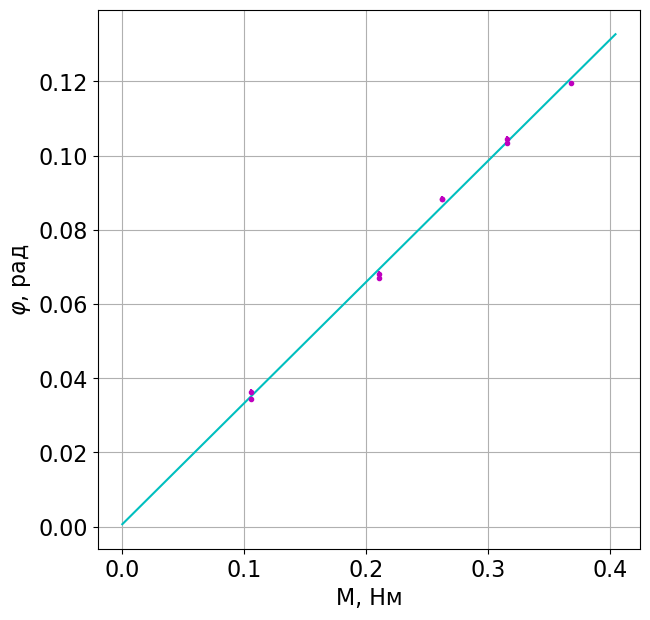

In [38]:
X1 = M
Y1 = F
err_X1 = dM
err_Y1 = dF
K1 = b
B1 = a

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.size'] = 16 
plt.figure(figsize=(7,7))


plt.ylabel(r"$\varphi$, рад")
plt.xlabel("M, Нм")

plt.errorbar(X1, Y1, yerr=err_Y1, xerr=err_X1, fmt='.m')

plt.grid(visible=True, which='major', axis='both', alpha=1)
plt.grid(visible=True, which='minor', axis='both', alpha=1)

x = np.linspace(0, max(X1)*1.1, 100)
y = K1*x + B1
plt.plot(x,y, "c")

#plt.legend()
plt.savefig('example.png')
plt.show()